<a href="https://colab.research.google.com/github/RGarancs/applied-ai-academy-labs/blob/main/solutions/tickets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Support tickets (synthetic)

**Applied AI Academy — problem set with worked answers**

**Used in:** Lesson 12 — Growth with AI is a trust budget — spend it carefully  
**Rows:** 180  ·  **Source file:** `support_tickets_sample.csv`



---
### How to use this notebook
Run the cells in order. Each problem is stated first, then solved, then the
answer is spelled out. For teaching, hide the solution cells and let the room
attempt the task before revealing them.

> The data loads straight from `appliedai.center` — nothing to upload.


## Setup

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, os, urllib.request
import matplotlib, matplotlib.pyplot as plt
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

# Applied AI Academy chart style — calm, legible when projected
INK, ACCENT, CORE, BUILDER, DANGER = "#26214a", "#544d94", "#5b8a6e", "#a8845c", "#b05a5a"
matplotlib.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c4d8", "axes.labelcolor": INK, "axes.titlesize": 13,
    "axes.titleweight": "600", "axes.titlecolor": INK, "axes.titlepad": 14,
    "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 10, "grid.color": "#e6e2ef", "axes.grid": True,
    "axes.axisbelow": True, "grid.linewidth": .8, "figure.facecolor": "white",
})

URL   = "https://appliedai.center/assets/datasets/support_tickets_sample.csv"
LOCAL = "support_tickets_sample.csv"
if not os.path.exists(LOCAL):
    print("Downloading", URL)
    urllib.request.urlretrieve(URL, LOCAL)

df = pd.read_csv(LOCAL, low_memory=False)
print("Shape:", df.shape)
df.head()

Shape: (180, 6)


,ticket_id,customer_segment,message,priority,resolved_hours,escalated
0,T0001,Enterprise,We need a data processing agreement for our le...,high,19.1,1
1,T0002,Enterprise,I want to upgrade but need a quote for 250 users.,low,3.1,0
2,T0003,SMB,I want to upgrade but need a quote for 250 users.,low,6.6,0
3,T0004,SMB,I was charged twice after changing my subscrip...,medium,8.1,0
4,T0005,Mid-market,We need a data processing agreement for our le...,medium,3.6,1


## What is in the file

In [2]:
print("Columns and types:")
print(df.dtypes.to_string())
miss = df.isna().sum()
miss = miss[miss > 0]
print("\nMissing values:" if len(miss) else "\nNo missing values.")
if len(miss): print(miss.to_string())

Columns and types:
ticket_id               str
customer_segment        str
message                 str
priority                str
resolved_hours      float64
escalated             int64

No missing values.


---
## Problem 1 · Easy — describe

How is support load distributed, and what gets escalated?

*Try it yourself first. The worked solution is below.*

In [3]:
print(f"Tickets: {len(df)}")
print(f"Escalation rate: {df['escalated'].mean():.1%}")
print("\nBy priority:")
print(df.groupby("priority").agg(tickets=("ticket_id","size"),
                                 escalation_rate=("escalated","mean"),
                                 median_hours=("resolved_hours","median")).round(2))
print("\nBy customer segment:")
print(df.groupby("customer_segment").agg(tickets=("ticket_id","size"),
                                         escalation_rate=("escalated","mean")).round(3))

Tickets: 180
Escalation rate: 58.3%

By priority:
          tickets  escalation_rate  median_hours
priority                                        
high           50             1.00         18.65
low            42             0.48          5.20
medium         88             0.40          5.75

By customer segment:
                  tickets  escalation_rate
customer_segment                          
Enterprise             60            0.600
Mid-market             58            0.621
SMB                    62            0.532


---
## Problem 2 · Intermediate — build

Which tickets are slow, and is slow the same as escalated?

*Try it yourself first. The worked solution is below.*

In [4]:
print("Resolution hours:\n", df["resolved_hours"].describe().round(2))
q = df["resolved_hours"].quantile(.9)
print(f"\n90th percentile: {q:.1f}h — the tail is where reputation is lost.")
slow = df[df["resolved_hours"] >= q]
print("\nSlowest decile by priority:\n", slow["priority"].value_counts())
print("\nEscalated vs not, median hours:")
print(df.groupby("escalated")["resolved_hours"].median().round(2))

Resolution hours:
 count    180.00
mean      12.01
std       10.43
min        0.00
25%        3.48
50%       10.25
75%       18.35
max       60.80
Name: resolved_hours, dtype: float64

90th percentile: 24.0h — the tail is where reputation is lost.

Slowest decile by priority:
 priority
high      8
medium    7
low       3
Name: count, dtype: int64

Escalated vs not, median hours:
escalated
0     5.8
1    13.7
Name: resolved_hours, dtype: float64


---
## Problem 3 · Advanced — judge

Triage rule: what would you automate, and what must stay human?

*Try it yourself first. The worked solution is below.*

In [5]:
import re
kw = ["refund","cancel","legal","angry","urgent","broken","invoice","gdpr","data"]
low = df["message"].astype(str).str.lower()
for k in kw:
    hit = low.str.contains(k)
    if hit.sum() >= 3:
        print(f"{k:<9} n={hit.sum():3d}  escalation={df.loc[hit,'escalated'].mean():.0%}  "
              f"median_h={df.loc[hit,'resolved_hours'].median():.1f}")
print("\nA keyword with a high escalation rate is a candidate for a HUMAN gate,")
print("not for automation. Automate the confident, reversible middle.")

cancel    n= 25  escalation=100%  median_h=7.9
legal     n= 29  escalation=100%  median_h=10.7
invoice   n= 22  escalation=36%  median_h=8.0
data      n= 45  escalation=78%  median_h=12.2

A keyword with a high escalation rate is a candidate for a HUMAN gate,
not for automation. Automate the confident, reversible middle.


---
## Visual summary

The same answers, as pictures. These are what to project — a room reads a chart
far faster than it reads a table, and the shape of a result is usually the
argument you are actually making.

findfont: Failed to find font weight 600, now using 700.


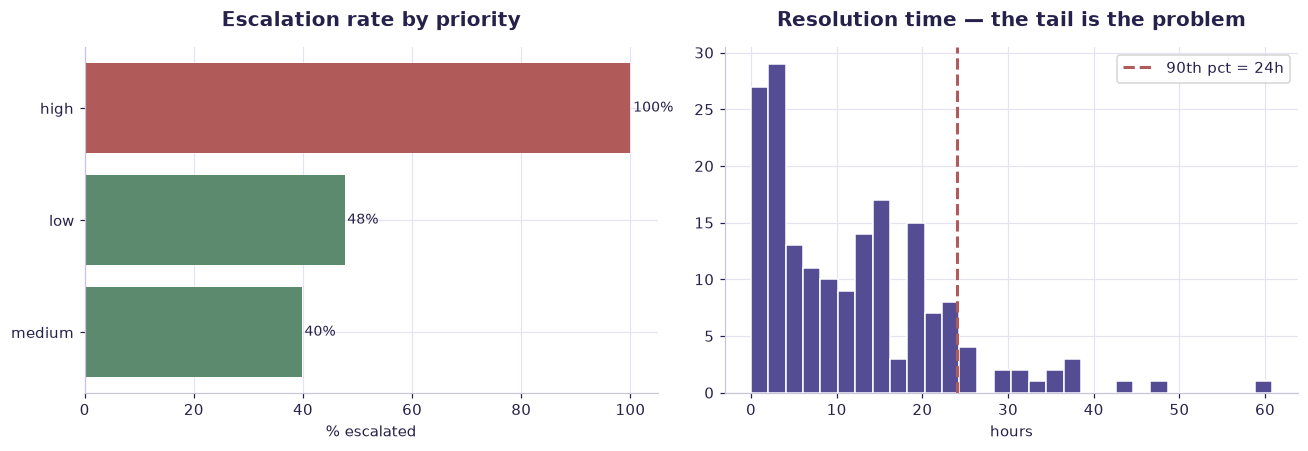

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
r = df.groupby("priority")["escalated"].mean().mul(100).sort_values()
ax[0].barh(r.index, r.values, color=[CORE if v < 50 else DANGER for v in r])
ax[0].set_title("Escalation rate by priority"); ax[0].set_xlabel("% escalated")
for i, v in enumerate(r.values): ax[0].text(v + .5, i, f"{v:.0f}%", va="center", fontsize=9)

ax[1].hist(df["resolved_hours"].dropna(), bins=30, color=ACCENT, edgecolor="white")
q = df["resolved_hours"].quantile(.9)
ax[1].axvline(q, color=DANGER, ls="--", lw=2, label=f"90th pct = {q:.0f}h")
ax[1].set_title("Resolution time — the tail is the problem"); ax[1].set_xlabel("hours"); ax[1].legend()
plt.tight_layout(); plt.show()

---
## Verified answer key

These are the numbers the academy ships for this dataset. They were computed
from this exact file — if your run disagrees, reconcile before teaching it.

1. Overall escalation 58.3% — NOT a routine-heavy corpus
2. Priority mix: high 50 · medium 88 · low 42
3. High priority: 100% escalation, 19.9h avg resolution → draft-for-human territory
4. Medium 40% / low 48% escalation → AI-first-response candidates, not autonomous closure


---
## Teaching notes

* **Run the Easy problem live.** It sets the shared vocabulary and gets everyone
  looking at the same rows.
* **Let them fail on the Intermediate one.** The productive mistake is usually
  reaching for a model before checking the data.
* **Argue about the Advanced one.** It has no single right answer; it has a
  defensible one, and defending it is the skill being taught.
* **Always close on limitations.** Every dataset here has a real caveat —
  scrape bias, a tiny sample, a hindsight label. Naming it is the lesson.
* **Deliverable for learners:** AI-enhanced journey map + triage design with explicit escalation rules.

---
*Applied AI Academy · appliedai.center*
